# Preprocessing pipeline

**Goal** here is to select a proper window of samples.

Apply **filtering** within the window to interpolate data during blinks

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.interpolate as cwi
from importlib import reload
reload(cwi)
reload(cwpre)
COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = [6]
EXPERIMENTS = [1,2,3,4]

In [187]:
# Load the dataset
eye_df = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print("Loaded eye-tracking data shape:", eye_df.shape)

There are 0 non matching timestamp_sec within the limits
Final merged dataset has 10377 records at 240 Hz
Final merged and resampled dataset has 2563 records at 60 Hz
There are 2 non matching timestamp_sec within the limits
Final merged dataset has 6194 records at 240 Hz
Final merged and resampled dataset has 1550 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 20616 records at 240 Hz
Final merged and resampled dataset has 5662 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 14682 records at 240 Hz
Final merged and resampled dataset has 3810 records at 60 Hz
Loaded eye-tracking data shape: (13585, 11)


In [159]:
# Checking the different cl values for subject id
display(eye_df[eye_df["subject_id"] == 6].groupby("task_id")["cl_class"].unique())

task_id
3    [high]
Name: cl_class, dtype: object

## A. Extract window

Extract a proper window for analysis. Also validates invididual methods used for preprocessing.

*A priori* using $T\approx 10s$ consisting of $N=512$ samples seems like a good start.

Thus, inference could be done on a *per second* basis, giving overlapping windows of N~448 samples

In [201]:
N = 2048 # Number of samples in the window
offset = 0 # Offset in # samples for the start of the window
fs = 60
SUBJECT_ID = 6
TASK_ID = 1

subject_df = eye_df[(eye_df["subject_id"] == SUBJECT_ID) & (eye_df["task_id"] == TASK_ID)].reset_index(drop=True)
print("Extracting a window of {} samples which corresponds to {:.2f} seconds".format(N, N/fs))
window_df = subject_df.iloc[offset:offset+N].copy()

window_df.head()

Extracting a window of 2048 samples which corresponds to 34.13 seconds


,timestamp_sec,norm_pos_x,norm_pos_y,gaze_point_3d_x,gaze_point_3d_y,gaze_point_3d_z,pupil_confidence,pupil_diameter_mm,subject_id,task_id,cl_class
0,0.00000,0.578754,0.542618,9.489177,-5.997289,69.096296,1.000000,28.009821,6,1,low
1,0.01667,0.573984,0.547381,9.206533,-6.478794,71.104947,1.000000,30.115034,6,1,low
2,0.03334,0.538154,0.552388,5.031886,-6.775096,71.139556,0.859343,29.620956,6,1,low
3,0.05001,0.531768,0.550176,4.220770,-6.516712,69.964390,1.000000,27.729935,6,1,low
4,0.06668,0.532079,0.550186,4.236455,-6.487348,69.640582,0.951795,29.826196,6,1,low


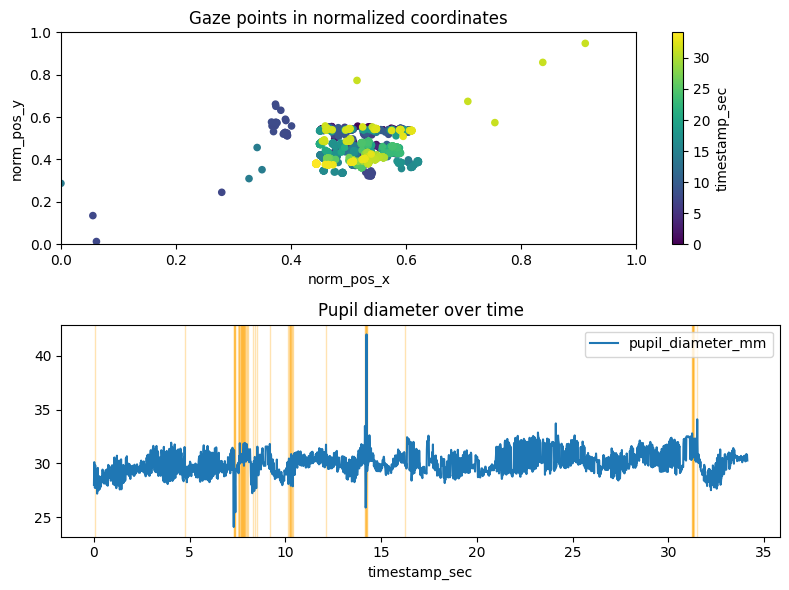

In [202]:
import matplotlib
# Visualize a bit the data in the window
fig = plt.figure(figsize=(8, 6), tight_layout=True)
ax0 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)
# Plot gaze data in normalized coordinates
colormap = matplotlib.colormaps['viridis']
ax0.set_xlim(0, 1)
ax0.set_ylim(0, 1)
window_df.plot("norm_pos_x", "norm_pos_y", kind='scatter', c='timestamp_sec', colormap=colormap, title="Gaze points in normalized coordinates", ax=ax0)

# Plot (best of the 2 eyes) pupil diameter over time 
window_df.plot("timestamp_sec", "pupil_diameter_mm", kind='line', title="Pupil diameter over time", ax=ax2)

# Overlay the blinks as vertical zones
# blink_df['blink_timestamp'] = blink_df['start_timestamp'] - window_df['timestamp_sec'].min() # Align blink timestamps with window timestamps
# blink_df_window = blink_df[(blink_df['blink_timestamp'] >= window_df['timestamp_sec'].min()) & (blink_df['blink_timestamp'] <= window_df['timestamp_sec'].max())]
# if blink_df_window.empty:
#     print("No (official) blinks detected in the current window.")
# for _, row in blink_df_window.iterrows():
#     ax2.axvspan(row['timestamp'], row['timestamp'] + row['duration'], color='red', alpha=0.3)

# Show low confidence zones
window_df['low_confidence'] = window_df['pupil_confidence'] < 0.95
for _, row in window_df[window_df.low_confidence].iterrows():
    ax2.axvspan(row['timestamp_sec'], row['timestamp_sec'] + 1.0/240, color='orange', alpha=0.3)

Skipping gap with insufficient data around start_id 2038.0 and stop_id 2038.0


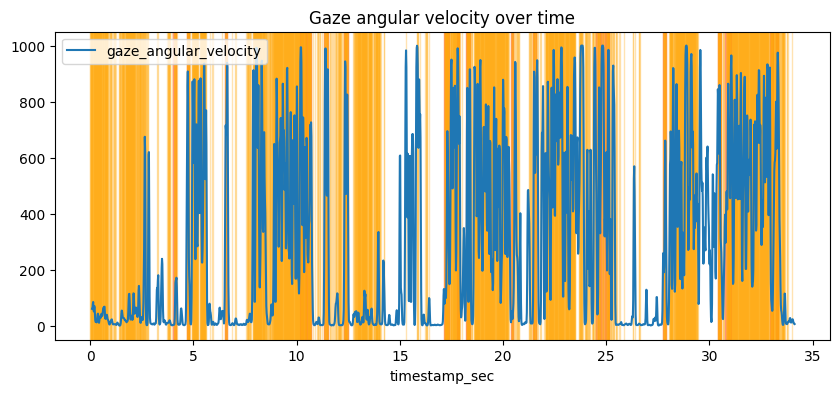

In [165]:
# Now calculate angular gaze data
import cognitive_models.gaze_utils as cwgaze
reload(cwgaze)
reload(cwi)
window_df['gaze_angle_delta_deg'] = cwgaze.calculate_gaze_angular_delta(window_df)
gaps_df, custom_blinks_df = cwgaze.detect_gaps_and_blinks(window_df)
window_df, inter_data_df = cwi.interpolate_blinks(window_df, custom_blinks_df)
window_df, inter_data2_df = cwi.interpolate_missing_gaze(window_df, gaps_df)
window_df['gaze_angular_velocity'] = cwgaze.calculate_angular_velocity(window_df)

# Plot 
fig, ax = plt.subplots(figsize=(10, 4))
window_df.plot("timestamp_sec", "gaze_angular_velocity", kind='line', title="Gaze angular velocity over time", ax=ax)
for _, row in custom_blinks_df.iterrows():
    ax.axvspan(row['start_timestamp'], row['stop_timestamp'], color='red', alpha=0.3)
for _, row in window_df[window_df['low_confidence']].iterrows():
    ax.axvspan(row['timestamp_sec'], row['timestamp_sec'] + 1.0/fs, color='orange', alpha=0.3)

Found 43 transitions between saccades and fixations
Will mark 0 short fixations as saccades


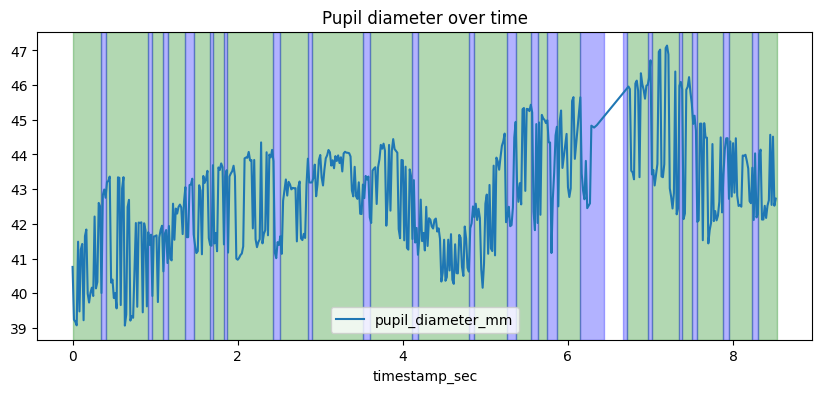

In [138]:
# Extract required features for the window
window_df, fixations_df, saccades_df = cwgaze.calculate_fixations_saccades(window_df, 45)

# Plot fixations / saccades zones
fig, ax = plt.subplots(figsize=(10, 4))
window_df.plot("timestamp_sec", "pupil_diameter_mm", kind='line', title="Pupil diameter over time", ax=ax)
for _, row in fixations_df.iterrows():
    ax.axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='green', alpha=0.3)
for _, row in saccades_df.iterrows():
    ax.axvspan(row['start_timestamp'], row['stop_timestamp'] + 1.0/fs, color='blue', alpha=0.3)


In [154]:
# Using the preprocessing function
import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
reload(cwgaze)
reload(cwpre)
reload(cwfeat)

feature_rows = []
for t in range(N, len(subject_df), 64):
    window_df = subject_df.iloc[t-N:t].reset_index(drop=True)
    window_preprocess_data, custom_blinks_df = cwpre.preprocess_colet_data(window_df, verbose=False)

    # Extract features
    features_dict = cwfeat.extract_window_features(window_preprocess_data, custom_blinks_df, ivt_threshold=45, min_fixation_duration=55, verbose=False)

    feature_rows.append(features_dict)

features_df = pd.DataFrame(feature_rows)
print("Extracted features shape:", features_df.shape)
features_df.head(10)


Skipping blink with insufficient data around start_id 2 and stop_id 14
Skipping gap with insufficient data around start_id 506.0 and stop_id 507.0
Extracted features shape: (24, 17)


,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_std,saccades_count,saccades_peak_velocity_mean,saccades_amplitude_mean,saccades_amplitude_max,saccades_amplitude_min,saccades_amplitude_std,saccades_duration_mean,saccades_duration_max,saccades_duration_min,saccades_duration_std,blinks_count,blinks_duration_mean
0,21,303.235238,600.12,100.02,163.299566,21,135.473886,1.053695,2.458072,0.000000,0.823823,58.741905,266.72,16.67,52.878083,1,0.20004
1,19,341.296316,1000.20,100.02,224.847234,19,144.199844,0.973782,2.458072,0.000000,0.816803,62.293158,266.72,16.67,54.682260,1,0.20004
2,17,387.332353,1450.29,100.02,313.839559,17,153.643234,0.786395,2.458072,0.000000,0.801538,67.660588,266.72,16.67,55.435767,1,0.20004
3,15,445.644667,1500.30,100.02,438.947526,16,155.879395,0.744528,2.458072,0.000000,0.751439,68.763750,266.72,16.67,56.735172,1,0.20004
4,15,448.978667,1500.30,100.02,437.724883,15,156.085099,0.638673,2.458072,0.000000,0.750320,71.125333,266.72,16.67,58.588306,1,0.20004
5,13,533.440000,1650.33,100.02,576.502493,13,162.071988,0.637962,2.458072,0.000000,0.787404,71.809231,266.72,16.67,62.885394,1,0.20004
6,13,553.956923,1683.67,100.02,570.248589,13,140.244582,0.808126,2.458072,0.000000,0.866731,48.727692,83.35,16.67,18.589776,1,0.20004
7,12,627.903333,1683.67,200.04,560.520182,12,98.714926,0.677317,2.141218,0.000001,0.705800,50.010000,83.35,16.67,18.806296,0,0.00000
8,13,579.603077,1683.67,50.01,570.207978,12,95.039807,0.580910,2.141218,0.000001,0.669863,48.620833,83.35,16.67,21.860574,0,0.00000
9,15,491.209333,1683.67,100.02,469.721719,14,97.221385,0.652037,2.141218,0.000001,0.685989,48.819286,83.35,16.67,20.115130,0,0.00000
